# 가설 1: 가격 민감도 - 최근 보험료 인상 고객일수록 이탈 확률이 높을 것이다

이 노트북은 보험 고객 이탈 예측 주제 중 **가격 민감도 가설**을 검증하기 위한 분석 노트북이다.  
현재 분석 범위는 다음 가설 하나에 집중한다.

- 가설 1: 최근 보험료가 인상된 고객일수록 이탈 확률이 높을 것이다.
- 분석 포인트: `premium_change_pct`와 `churn_flag`의 관계 분석
- 주요 컬럼: `current_premium`, `premium_last_year`, `premium_change_pct`, `num_price_increases_last_3y`, `policy_type`, `churn_flag`


In [1]:
# 필요한 라이브러리를 불러온다.
# 시각화는 matplotlib만 사용하고, 별도 색상 지정은 하지 않는다.

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 데이터 수집 및 확인

본 분석에서는 보험 고객 이탈 데이터셋을 사용한다.  
데이터에는 고객의 보험 유형, 보험료 변화, 보험금 청구 이력, 불만 여부, 이탈 여부 등이 포함되어 있다.

이번 가설에서는 특히 아래 변수들을 중심으로 확인한다.

- `current_premium`: 현재 보험료
- `premium_last_year`: 전년도 보험료
- `premium_change_pct`: 보험료 변화율
- `num_price_increases_last_3y`: 최근 3년 보험료 인상 횟수
- `policy_type`: 보험 상품 유형
- `churn_flag`: 고객 이탈 여부


In [2]:
# 프로젝트 루트를 찾은 뒤, 공통 전처리 모듈을 import 한다.
# 노트북은 __file__ 을 직접 쓰기 어렵기 때문에 현재 작업 폴더와 상위 폴더를 순회한다.

def find_project_root():
    start = Path.cwd().resolve()
    candidates = [start] + list(start.parents)

    for base in candidates:
        if (base / "src" / "preprocess.py").exists():
            return base

    raise FileNotFoundError(
        "Project root not found. Expected a folder containing src/preprocess.py"
    )

project_root = find_project_root()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocess import load_data

# 인수인계 받은 공통 로더를 사용한다.
df = load_data()

# 현재 공통 전처리 함수는 반환값 반영 문제로 일부 컬럼이 남을 수 있어,
# 노트북에서는 안전하게 한 번 더 제거한다.
safe_drop_cols = [
    "customer_id",
    "as_of_date",
    "churn_type",
    "churn_probability_true",
]

df = df.drop(columns=[col for col in safe_drop_cols if col in df.columns]).copy()

print("project_root:", project_root)
print("shape:", df.shape)

display(df.head())
display(df[[
    "current_premium",
    "premium_last_year",
    "premium_change_pct",
    "num_price_increases_last_3y",
    "policy_type",
    "churn_flag",
]].head())

df.info()

project_root: C:\lecture\PRED-CUST-CHURN
shape: (50000, 36)


,region_name,age,age_band,marital_status,customer_tenure_months,multi_policy_flag,num_policies,policy_type,renewal_month,current_premium,premium_last_year,premium_change_pct,num_price_increases_last_3y,coverage_amount,premium_to_coverage_ratio,payment_frequency,autopay_enabled,late_payment_count_12m,missed_payment_flag,payment_method_change_flag,num_claims_12m,num_approved_claims_12m,num_rejected_claims_12m,num_pending_claims_12m,avg_claim_amount,total_claim_amount_12m,total_payout_amount_12m,payout_ratio_12m,avg_settlement_time_days,days_since_last_claim,num_contacts_12m,complaint_flag,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,churn_flag
0,Manawatu-Whanganui,24,18-24,Married,128,1,4,Auto,8,"1,013.4700","1,060.0400",-0.0365,1,"8,924.0900",0.1136,Monthly,1,0,0,0,0,0,0,0,"5,250.1900",0.0000,0.0000,0.7500,7,1616,0,0,0,0,0,0
1,Auckland,70,65-74,Married,76,1,3,Auto,3,"1,126.9000","1,052.2700",0.0479,2,"43,734.4500",0.0258,Monthly,1,0,0,0,0,0,0,0,"4,141.4100",0.0000,0.0000,0.7500,15,1760,1,0,0,0,0,0
2,Bay of Plenty,62,55-64,Married,129,0,1,Auto,5,984.7000,874.2900,0.1184,1,"23,152.3700",0.0425,Annual,0,0,0,0,0,0,0,0,"1,956.4200",0.0000,0.0000,0.7500,24,1581,1,0,0,0,0,0
3,Bay of Plenty,47,45-54,Single,104,0,1,Auto,2,373.6100,331.9900,0.1502,2,"31,806.9500",0.0117,Monthly,1,2,0,0,0,0,0,0,"3,204.5400",0.0000,0.0000,0.7500,17,1688,1,0,0,0,0,0
4,Bay of Plenty,47,45-54,Married,22,1,3,Life,11,974.1800,991.8200,0.0161,1,"302,831.0200",0.0032,Monthly,1,0,0,0,0,0,0,0,"52,392.5900",0.0000,0.0000,0.8500,24,1592,1,0,0,0,0,0


,current_premium,premium_last_year,premium_change_pct,num_price_increases_last_3y,policy_type,churn_flag
0,"1,013.4700","1,060.0400",-0.0365,1,Auto,0
1,"1,126.9000","1,052.2700",0.0479,2,Auto,0
2,984.7000,874.2900,0.1184,1,Auto,0
3,373.6100,331.9900,0.1502,2,Auto,0
4,974.1800,991.8200,0.0161,1,Life,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   region_name                  50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   age_band                     50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   customer_tenure_months       50000 non-null  int64  
 5   multi_policy_flag            50000 non-null  int64  
 6   num_policies                 50000 non-null  int64  
 7   policy_type                  50000 non-null  object 
 8   renewal_month                50000 non-null  int64  
 9   current_premium              50000 non-null  float64
 10  premium_last_year            50000 non-null  float64
 11  premium_change_pct           50000 non-null  float64
 12  num_price_increases_last_3y  50000 non-null  int64  
 13  coverage_amount 

## 분석용 변수 생성

보험료 인상이 고객 이탈에 어떤 영향을 주는지 보기 위해 몇 가지 파생 변수를 생성한다.

우선 고객을 보험료 인상 여부에 따라 나누기 위해 `premium_increased` 변수를 생성한다.  
또한 보험료 변화율을 구간별로 나누어 인상 폭이 작을 때와 클 때의 차이를 비교한다.

단순히 현재 보험료 수준만 보는 것보다,  
작년 대비 보험료가 얼마나 변했는지를 나타내는 `premium_change_pct`가 가격 부담을 더 직접적으로 보여줄 수 있다.

In [3]:
# 분석 전용 데이터프레임을 별도로 만든다.
# 원본을 유지한 상태에서 파생 변수를 추가하기 위함이다.

analysis_df = df.copy()

# 보험료가 실제로 인상되었는지 여부를 0/1로 만든다.
analysis_df["premium_increased"] = (analysis_df["premium_change_pct"] > 0).astype(int)

# 보험료 변화율 구간을 만든다.
analysis_df["premium_change_bin"] = pd.cut(
    analysis_df["premium_change_pct"],
    bins=[-np.inf, 0, 0.05, 0.10, np.inf],
    labels=["<=0%", "0-5%", "5-10%", "10%+"],
    include_lowest=True,
)

# 이후 표와 그래프에서 보기 좋게 사용할 라벨 컬럼을 만든다.
analysis_df["premium_increased_label"] = analysis_df["premium_increased"].map({
    0: "No increase",
    1: "Increase",
})

display(
    analysis_df[[
        "premium_change_pct",
        "premium_increased",
        "premium_change_bin",
        "premium_increased_label",
        "churn_flag",
    ]].head(10)
)

,premium_change_pct,premium_increased,premium_change_bin,premium_increased_label,churn_flag
0,-0.0365,0,<=0%,No increase,0
1,0.0479,1,0-5%,Increase,0
2,0.1184,1,10%+,Increase,0
3,0.1502,1,10%+,Increase,0
4,0.0161,1,0-5%,Increase,0
5,0.0309,1,0-5%,Increase,0
6,0.0342,1,0-5%,Increase,1
7,-0.0057,0,<=0%,No increase,0
8,0.1516,1,10%+,Increase,1
9,0.0419,1,0-5%,Increase,0


In [4]:
# 반복 사용을 위해 간단한 보조 함수를 만든다.

def add_pct_columns(frame, rate_col):
    result = frame.copy()
    result[rate_col + "_pct"] = (result[rate_col] * 100).round(2)
    return result

def annotate_bar_percent(ax, values):
    for idx, value in enumerate(values):
        ax.text(idx, value, f"{value * 100:.1f}%", ha="center", va="bottom")

def set_percent_axis(ax):
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, max(ax.get_ylim()[1], 0.5))

## 1. 보험료 인상 여부에 따른 이탈률 비교

먼저 고객을 보험료 인상 여부에 따라 두 그룹으로 나누고, 각 그룹의 평균 이탈률을 비교한다.

이 단계에서는 보험료가 오른 고객과 그렇지 않은 고객 사이의 차이를 확인하여,  
가격 인상 자체가 고객 유지에 부정적인 영향을 주는지 살펴본다.

,premium_increased_label,customers,churn_rate,churn_rate_pct
0,No increase,11657,0.1780,17.8000
1,Increase,38343,0.3393,33.9300


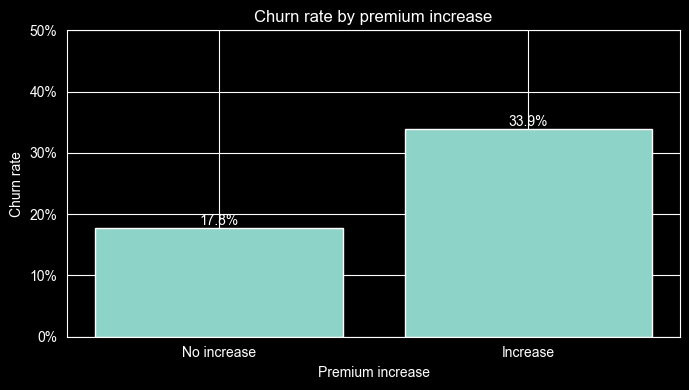

In [5]:
# 보험료 인상 여부별 고객 수와 이탈률을 계산한다.
# customer_id 는 공통 전처리에서 제거되므로, 행 개수 기준으로 고객 수를 센다.

summary_increase = (
    analysis_df
    .groupby("premium_increased_label", as_index=False)
    .agg(
        customers=("churn_flag", "size"),
        churn_rate=("churn_flag", "mean"),
    )
)

summary_increase["premium_increased_label"] = pd.Categorical(
    summary_increase["premium_increased_label"],
    categories=["No increase", "Increase"],
    ordered=True,
)
summary_increase = summary_increase.sort_values("premium_increased_label").reset_index(drop=True)

display(add_pct_columns(summary_increase, "churn_rate"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(summary_increase["premium_increased_label"], summary_increase["churn_rate"])
ax.set_title("Churn rate by premium increase")
ax.set_xlabel("Premium increase")
ax.set_ylabel("Churn rate")
set_percent_axis(ax)
annotate_bar_percent(ax, summary_increase["churn_rate"].to_list())
plt.tight_layout()
plt.show()

보험료 인상 여부에 따라 이탈률을 비교한 결과, 보험료가 인상된 고객 집단의 이탈률이 인상되지 않은 고객보다 높게 나타나는지 확인할 수 있다.

이 결과는 고객이 보험료 상승을 체감할 경우 계약 유지 의사가 약해질 수 있음을 보여주며,  
가격 인상이 고객 이탈과 밀접한 관련이 있음을 시사한다.

## 2. 보험료 변화율 구간별 이탈률 비교

다음으로 보험료 변화율을 몇 개 구간으로 나누어 비교한다.  
이 분석은 단순히 보험료가 올랐는지를 넘어서, 인상 폭이 커질수록 실제로 이탈률도 높아지는지 확인하는 과정이다.

만약 인상 폭이 클수록 이탈률이 함께 증가한다면,  
보험료 상승 자체뿐 아니라 상승 정도 역시 고객의 유지 여부에 중요한 영향을 준다고 볼 수 있다.

,premium_change_bin,customers,churn_rate,churn_rate_pct
0,<=0%,11657,0.1780,17.8000
1,0-5%,11019,0.2128,21.2800
2,5-10%,11609,0.3059,30.5900
3,10%+,15715,0.4526,45.2600


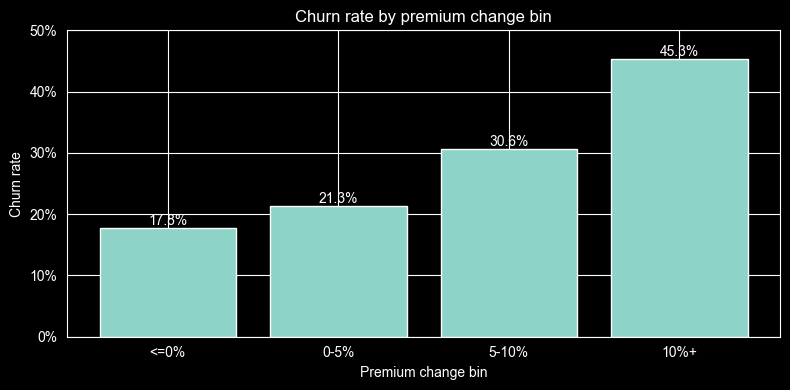

In [6]:
# 보험료 변화율 구간별 이탈률을 계산한다.

summary_change_bin = (
    analysis_df
    .groupby("premium_change_bin", observed=False, as_index=False)
    .agg(
        customers=("churn_flag", "size"),
        churn_rate=("churn_flag", "mean"),
    )
)

display(add_pct_columns(summary_change_bin, "churn_rate"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary_change_bin["premium_change_bin"].astype(str), summary_change_bin["churn_rate"])
ax.set_title("Churn rate by premium change bin")
ax.set_xlabel("Premium change bin")
ax.set_ylabel("Churn rate")
set_percent_axis(ax)
annotate_bar_percent(ax, summary_change_bin["churn_rate"].to_list())
plt.tight_layout()
plt.show()

보험료 변화율 구간별 이탈률을 비교하면, 인상 폭이 커질수록 이탈률도 함께 증가하는 흐름이 나타나는지 확인할 수 있다.

특히 큰 폭으로 보험료가 오른 고객군에서 이탈률이 높게 나타난다면,  
고객은 단순한 인상 여부보다 인상 폭 자체에 더 민감하게 반응한다고 해석할 수 있다.

## 3. 최근 3년 보험료 인상 횟수와 이탈 관계

보험료는 한 번 크게 오르는 경우뿐 아니라, 여러 차례 반복적으로 인상되는 경우에도 고객에게 부담이 될 수 있다.  
따라서 최근 3년간 보험료가 몇 번 인상되었는지에 따라 이탈률이 달라지는지 함께 확인한다.

이 분석은 가격 부담의 누적 효과를 확인하는 단계이다.

,num_price_increases_last_3y,customers,churn_rate,churn_rate_pct
0,0,3473,0.1785,17.8500
1,1,17347,0.2881,28.8100
2,2,21419,0.3175,31.7500
3,3,7761,0.3434,34.3400


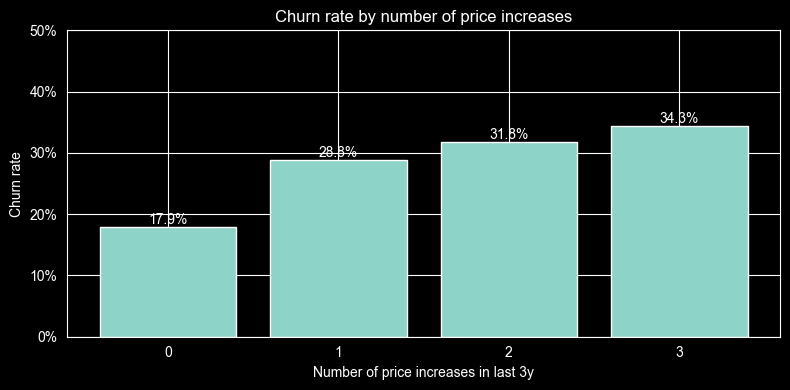

In [7]:
# 최근 3년 보험료 인상 횟수별 이탈률을 계산한다.

summary_increase_count = (
    analysis_df
    .groupby("num_price_increases_last_3y", as_index=False)
    .agg(
        customers=("churn_flag", "size"),
        churn_rate=("churn_flag", "mean"),
    )
    .sort_values("num_price_increases_last_3y")
    .reset_index(drop=True)
)

display(add_pct_columns(summary_increase_count, "churn_rate"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary_increase_count["num_price_increases_last_3y"].astype(str), summary_increase_count["churn_rate"])
ax.set_title("Churn rate by number of price increases")
ax.set_xlabel("Number of price increases in last 3y")
ax.set_ylabel("Churn rate")
set_percent_axis(ax)
annotate_bar_percent(ax, summary_increase_count["churn_rate"].to_list())
plt.tight_layout()
plt.show()

최근 3년간 보험료 인상 횟수와 이탈률을 비교하면, 인상 횟수가 많을수록 이탈률이 함께 증가하는지 확인할 수 있다.

이 결과는 고객이 일회성 가격 인상뿐 아니라, 반복적인 보험료 상승에도 민감하게 반응한다는 점을 보여준다.  
즉 가격 부담은 누적될수록 이탈 가능성을 더욱 높일 수 있다.

## 4. 보험 유형별 차이 확인

보험료 인상이 모든 보험 상품에서 동일한 영향을 주는 것은 아닐 수 있다.  
자동차 보험, 건강 보험, 생명 보험, 주택 보험 등은 고객의 필요도와 대체 가능성이 다르기 때문에 가격 민감도 역시 차이가 날 수 있다.

따라서 보험 유형별로 보험료 인상 여부에 따른 이탈률 차이를 확인하여,  
어떤 상품군에서 가격 인상의 영향이 더 크게 나타나는지 살펴본다.

,policy_type,premium_increased_label,customers,churn_rate,churn_rate_pct
0,Auto,No increase,3746,0.1805,18.0500
1,Auto,Increase,12353,0.3430,34.3000
2,Health,No increase,2714,0.1717,17.1700
3,Health,Increase,9173,0.3456,34.5600
4,Home,No increase,2822,0.1821,18.2100
5,Home,Increase,9156,0.3321,33.2100
6,Life,No increase,1681,0.1808,18.0800
7,Life,Increase,5400,0.3324,33.2400
8,Travel,No increase,694,0.1657,16.5700
9,Travel,Increase,2261,0.3383,33.8300


premium_increased_label,No increase,Increase
policy_type,,
Auto,18.0500,34.3000
Health,17.1700,34.5600
Home,18.2100,33.2100
Life,18.0800,33.2400
Travel,16.5700,33.8300


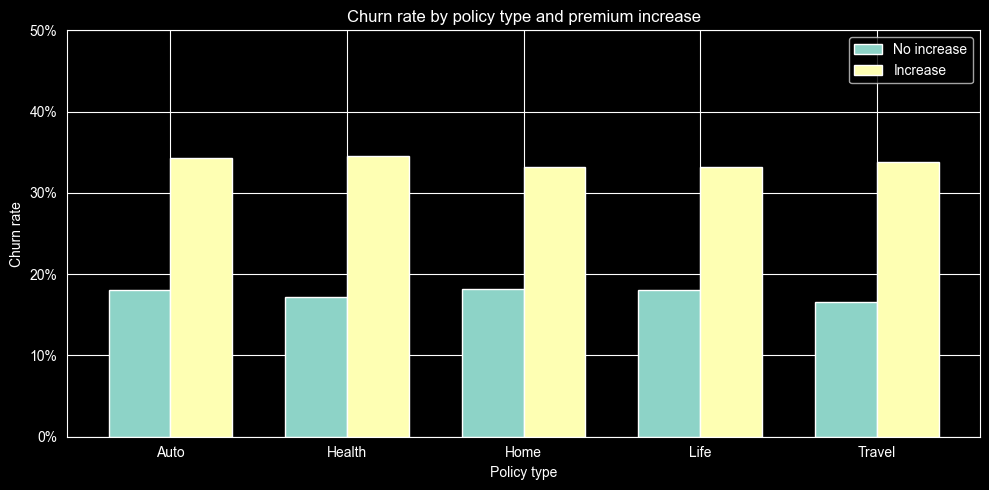

In [9]:
# 보험 유형과 보험료 인상 여부를 함께 보아 상품군별 차이를 확인한다.

summary_policy = (
    analysis_df
    .groupby(["policy_type", "premium_increased_label"], as_index=False)
    .agg(
        customers=("churn_flag", "size"),
        churn_rate=("churn_flag", "mean"),
    )
)

summary_policy["premium_increased_label"] = pd.Categorical(
    summary_policy["premium_increased_label"],
    categories=["No increase", "Increase"],
    ordered=True,
)
summary_policy = summary_policy.sort_values(["policy_type", "premium_increased_label"]).reset_index(drop=True)

display(add_pct_columns(summary_policy, "churn_rate"))

policy_pivot = (
    summary_policy
    .pivot(index="policy_type", columns="premium_increas"
                                        "ed_label", values="churn_rate")
    .reindex(columns=["No increase", "Increase"])
)

display((policy_pivot * 100).round(2))

x = np.arange(len(policy_pivot.index))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, policy_pivot["No increase"], width, label="No increase")
ax.bar(x + width / 2, policy_pivot["Increase"], width, label="Increase")
ax.set_title("Churn rate by policy type and premium increase")
ax.set_xlabel("Policy type")
ax.set_ylabel("Churn rate")
ax.set_xticks(x)
ax.set_xticklabels(policy_pivot.index)
set_percent_axis(ax)
ax.legend()
plt.tight_layout()
plt.show()

보험 유형별 결과를 보면, 대부분의 보험 유형에서 보험료가 인상된 고객의 이탈률이 인상되지 않은 고객보다 높게 나타나는지 확인할 수 있다.

즉 보험료 인상의 영향은 특정 보험에만 국한되지 않고, 전반적인 상품군에서 공통적으로 관찰되는 경향이라고 해석할 수 있다.  
다만 보험 유형에 따라 상승 폭의 크기에는 차이가 있을 수 있으므로, 실제 운영에서는 상품별 가격 정책을 세분화하여 관리할 필요가 있다.

## 분석 요약

이번 분석에서는 보험료 인상과 고객 이탈 사이의 관계를 단계적으로 확인하였다.

1. 보험료가 인상된 고객의 이탈률은 인상되지 않은 고객보다 높은지 확인했다.
2. 보험료 변화율이 커질수록 이탈률도 함께 증가하는 경향이 있는지 확인했다.
3. 최근 3년간 보험료 인상 횟수가 많을수록 이탈률이 높아지는지 확인했다.
4. 이러한 경향이 보험 유형별로도 비슷하게 나타나는지 확인했다.

즉 본 데이터에서는 가격 요인이 고객 이탈에 중요한 영향을 주는 변수로 해석될 수 있다.

In [10]:
# 핵심 수치를 한 번에 보기 좋게 정리한다.

final_summary = {
    "premium_increase": add_pct_columns(summary_increase, "churn_rate"),
    "premium_change_bin": add_pct_columns(summary_change_bin, "churn_rate"),
    "price_increase_count": add_pct_columns(summary_increase_count, "churn_rate"),
    "policy_type": add_pct_columns(summary_policy, "churn_rate"),
}

for name, table in final_summary.items():
    print("\n" + "=" * 80)
    print(name)
    display(table)


premium_increase


,premium_increased_label,customers,churn_rate,churn_rate_pct
0,No increase,11657,0.1780,17.8000
1,Increase,38343,0.3393,33.9300



premium_change_bin


,premium_change_bin,customers,churn_rate,churn_rate_pct
0,<=0%,11657,0.1780,17.8000
1,0-5%,11019,0.2128,21.2800
2,5-10%,11609,0.3059,30.5900
3,10%+,15715,0.4526,45.2600



price_increase_count


,num_price_increases_last_3y,customers,churn_rate,churn_rate_pct
0,0,3473,0.1785,17.8500
1,1,17347,0.2881,28.8100
2,2,21419,0.3175,31.7500
3,3,7761,0.3434,34.3400



policy_type


,policy_type,premium_increased_label,customers,churn_rate,churn_rate_pct
0,Auto,No increase,3746,0.1805,18.0500
1,Auto,Increase,12353,0.3430,34.3000
2,Health,No increase,2714,0.1717,17.1700
3,Health,Increase,9173,0.3456,34.5600
4,Home,No increase,2822,0.1821,18.2100
5,Home,Increase,9156,0.3321,33.2100
6,Life,No increase,1681,0.1808,18.0800
7,Life,Increase,5400,0.3324,33.2400
8,Travel,No increase,694,0.1657,16.5700
9,Travel,Increase,2261,0.3383,33.8300


## 분석결과

분석 결과, 최근 보험료가 인상된 고객일수록 실제 이탈 확률이 높아지는 경향을 확인할 수 있다.
특히 보험료 인상 폭이 크거나, 최근 몇 년간 반복적으로 보험료가 오른 고객일수록 이탈률이 더 높아지는지 함께 살펴볼 수 있었다.
따라서 보험 고객 이탈 관리 전략에서 보험료 변화는 핵심 모니터링 지표로 활용될 수 있다.

## 5. 가설 기반 이탈 예측 모델 학습

앞선 분석에서는 보험료 인상 여부, 보험료 변화율, 최근 3년 인상 횟수와 고객 이탈 사이의 관계를 확인하였다.

이번에는 가격 민감도 가설과 직접적으로 연결되는 변수들을 사용하여 실제 이탈 예측 모델을 학습한다.
현재는 보험료 관련 변수 중심으로 모델을 구성하되, 이후 다른 가설 변수들을 쉽게 추가할 수 있도록 확장 가능한 형태로 설계한다.

- 입력 변수: 보험료 및 가격 관련 변수 + 보험 유형
- 목표 변수: `churn_flag`
- 모델: Logistic Regression

### 5.1 모델 분리 및 학습

앞에서 만든 `analysis_df`를 그대로 사용하여 가설 중심 변수만으로 간단한 이탈 예측 모델을 학습한다.  
현재는 보험료 관련 변수와 보험 유형만 사용하며, 이후 다른 가설 변수를 같은 방식으로 쉽게 추가할 수 있다.

- 입력 변수: `current_premium`, `premium_last_year`, `premium_change_pct`, `num_price_increases_last_3y`, `policy_type`
- 목표 변수: `churn_flag`
- 모델: Logistic Regression

In [11]:
# 가설 중심 변수만 사용해 간단한 이탈 예측 모델을 만든다.

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

numeric_features = [
    "current_premium",
    "premium_last_year",
    "premium_change_pct",
    "num_price_increases_last_3y",
]

categorical_features = [
    "policy_type",
]

feature_cols = numeric_features + categorical_features
target_col = "churn_flag"

model_df = analysis_df[feature_cols + [target_col]].copy()

# X 는 입력 변수, y 는 정답값이다.
X = model_df[feature_cols]
y = model_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("target mean:", round(y.mean(), 4))

# 학습용 데이터와 평가용 데이터를 나눈다.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# 수치형과 범주형을 각각 전처리한다.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 전처리와 모델을 하나의 파이프라인으로 묶는다.
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)

# 모델을 학습하고 예측한다.
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 기본 성능 지표를 확인한다.
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n[Model metrics]")
print("accuracy :", round(acc, 4))
print("precision:", round(prec, 4))
print("recall   :", round(rec, 4))
print("f1-score :", round(f1, 4))

# 혼동행렬과 분류 리포트를 확인한다.
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["actual_0", "actual_1"],
    columns=["pred_0", "pred_1"],
)

print("\n[Confusion matrix]")
display(cm_df)

print("\n[Classification report]")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

# 어떤 변수가 더 크게 작용했는지 간단히 본다.
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "abs_coefficient": np.abs(coefficients),
    }
).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

print("\n[Top coefficients]")
display(coef_df.head(10))

X shape: (50000, 5)
y shape: (50000,)
target mean: 0.3017

[Model metrics]
accuracy : 0.7075
precision: 0.5777
recall   : 0.1134
f1-score : 0.1895

[Confusion matrix]


,pred_0,pred_1
actual_0,6733,250
actual_1,2675,342



[Classification report]
              precision    recall  f1-score   support

           0     0.7157    0.9642    0.8215      6983
           1     0.5777    0.1134    0.1895      3017

    accuracy                         0.7075     10000
   macro avg     0.6467    0.5388    0.5055     10000
weighted avg     0.6740    0.7075    0.6309     10000


[Top coefficients]


,feature,coefficient,abs_coefficient
0,num__premium_change_pct,0.6114,0.6114
1,cat__policy_type_Health,-0.4206,0.4206
2,cat__policy_type_Life,-0.2609,0.2609
3,num__premium_last_year,0.2364,0.2364
4,cat__policy_type_Travel,0.2348,0.2348
5,cat__policy_type_Auto,-0.1699,0.1699
6,cat__policy_type_Home,-0.0651,0.0651
7,num__num_price_increases_last_3y,-0.0225,0.0225
8,num__current_premium,0.0055,0.0055


### 5.2 모델 결과 해석

위 결과를 통해 보험료 관련 변수만으로도 고객 이탈을 어느 정도 예측할 수 있는지 확인할 수 있다.  
특히 `premium_change_pct`, `num_price_increases_last_3y`와 같은 가격 관련 변수의 계수가 크게 나타난다면,  
가격 민감도 가설은 단순한 시각화 결과를 넘어 실제 예측 모델에서도 의미 있는 설명력을 가진다고 해석할 수 있다.

또한 이후 다른 가설을 합칠 때는 입력 변수 목록에 해당 변수만 추가하면 같은 구조로 확장할 수 있다.